<a href="https://colab.research.google.com/github/cabaret0p/data_analysis_tabel_harga_daging_ayam_ras/blob/main/data_analysis_tabel_harga_daging_ayam_ras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicken Price Analysis Setup

In [1]:
# Import necessary libraries
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd

# 1. Authenticate your Google account
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Open the Google Sheet
# Make sure the name exactly matches the file in your Google Drive
worksheet = gc.open('tabel_harga_daging_ayam_ras').sheet1

# 3. Fetch the data and convert it to a pandas DataFrame
rows = worksheet.get_all_values()

# Set the first row as the header and the rest as the data
df = pd.DataFrame.from_records(rows[1:], columns=rows[0])

# Display the first 5 rows to confirm it loaded correctly
df.head()

,No,Komoditas (Rp),01/ 01/ 2021,01/ 02/ 2021,01/ 03/ 2021,01/ 04/ 2021,03/ 05/ 2021,01/ 06/ 2021,01/ 07/ 2021,02/ 08/ 2021,...,01/ 05/ 2025,02/ 06/ 2025,01/ 07/ 2025,01/ 08/ 2025,01/ 09/ 2025,01/ 10/ 2025,03/ 11/ 2025,01/ 12/ 2025,01/ 01/ 2026,02/ 02/ 2026
0,I,Semua Provinsi,-,"33,550","34,300","34,750","36,000","41,800","35,950","32,100",...,"34,500","35,800","35,200","35,850","36,650","38,850","37,850","40,350","41,600","40,300"
1,II,Jawa Timur,-,"31,200","30,800","33,950","35,800",-,"29,650","29,350",...,"30,400","31,650","31,750","31,350","34,600","38,150","35,200","37,500","36,500","36,650"
2,1,Kota Surabaya,-,"30,250","30,750","34,500","35,250",-,"30,750","28,000",...,"31,500","32,750","33,000","32,750","35,500","38,500","36,000","38,250","37,750","36,750"
3,a,Pasar Wonokromo,-,"30,500","32,000","35,000","35,000",-,"32,500","30,000",...,"33,000","34,000","34,000","34,000","36,500","39,500","37,000","38,500","39,000","38,000"
4,b,Pasar Tambah Rejo,-,"30,000","29,500","34,000","35,500",-,"29,000","26,000",...,"30,000","31,500","32,000","31,500","34,500","37,500","35,000","38,000","36,500","35,500"


In [2]:
# 1. Drop the 'No' column if it exists, as it's just an unnecessary index
if 'No' in df.columns:
    df = df.drop(columns=['No'])

# 2. Rename the main column to 'Lokasi'
df = df.rename(columns={'Komoditas (Rp)': 'Lokasi'})

# 3. Pivot (melt) the table from wide to long format
# id_vars keeps 'Lokasi' intact, while the date columns get stacked
df_long = pd.melt(df, id_vars=['Lokasi'], var_name='Date', value_name='Price')

# 4. Clean and format the 'Price' column
# Remove commas (e.g., "33,500" -> "33500") and coerce missing "-" values to NaN
df_long['Price'] = df_long['Price'].astype(str).str.replace(',', '')
df_long['Price'] = pd.to_numeric(df_long['Price'], errors='coerce')

# 5. Clean and format the 'Date' column
# Remove the extra spaces in dates like '01/ 02/ 2021' -> '01/02/2021'
df_long['Date'] = df_long['Date'].astype(str).str.replace(' ', '')
# Convert to standard datetime objects assuming Day/Month/Year format
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%d/%m/%Y')

# Let's drop any rows where the Lokasi might be completely blank or empty
df_long = df_long[df_long['Lokasi'].str.strip() != '']

# Display the transformed dataframe
df_long.head(10)

,Lokasi,Date,Price
0,Semua Provinsi,2021-01-01,NaN
1,Jawa Timur,2021-01-01,NaN
2,Kota Surabaya,2021-01-01,NaN
3,Pasar Wonokromo,2021-01-01,NaN
4,Pasar Tambah Rejo,2021-01-01,NaN
5,Semua Provinsi,2021-02-01,33550.0
6,Jawa Timur,2021-02-01,31200.0
7,Kota Surabaya,2021-02-01,30250.0
8,Pasar Wonokromo,2021-02-01,30500.0
9,Pasar Tambah Rejo,2021-02-01,30000.0


In [3]:
import numpy as np

# 1. Drop rows where the 'Price' is missing (NaN)
df_long = df_long.dropna(subset=['Price'])

# 2. Clean up the text by removing leading/trailing spaces
df_long['Lokasi'] = df_long['Lokasi'].str.strip()

# 3. Create a 'Location_Type' column to distinguish markets, cities, and provinces
df_long['Location_Type'] = np.where(
    df_long['Lokasi'].str.lower().str.contains('pasar'), 'Market',
    np.where(df_long['Lokasi'].str.lower().str.contains('kota|kabupaten'), 'City', 'Province')
)

# 4. Sort the dataset by Location, then by Date
df_long = df_long.sort_values(by=['Lokasi', 'Date']).reset_index(drop=True)

# Preview the fully cleaned data
df_long.head(10)

,Lokasi,Date,Price,Location_Type
0,Jawa Timur,2021-02-01,31200.0,Province
1,Jawa Timur,2021-03-01,30800.0,Province
2,Jawa Timur,2021-04-01,33950.0,Province
3,Jawa Timur,2021-05-03,35800.0,Province
4,Jawa Timur,2021-07-01,29650.0,Province
5,Jawa Timur,2021-08-02,29350.0,Province
6,Jawa Timur,2021-09-01,31700.0,Province
7,Jawa Timur,2021-10-01,31250.0,Province
8,Jawa Timur,2021-11-01,32750.0,Province
9,Jawa Timur,2021-12-01,32650.0,Province


In [13]:
import numpy as np

# 1. Add Weather Season Feature
# Extract the month to determine the general Indonesian season
df_long['Month'] = df_long['Date'].dt.month
# April (4) through September (9) is typically the dry season
df_long['Season'] = np.where(df_long['Month'].isin([4, 5, 6, 7, 8, 9]), 'Kemarau (Dry)', 'Hujan (Rainy)')


# 2. Add Festive Period Feature
# This function maps dates to high-demand shopping windows rather than just the exact holiday
def assign_holiday_period_monthly(date):
    year = date.year
    month = date.month

    # Fixed Gregorian Holidays (Tag the whole month)
    if month == 12: return 'Christmas Lead-up'
    if month == 1: return 'New Year'

    # Movable Islamic Holidays (Tag the month(s) encompassing the fasting/festivities)
    if year == 2021 and month in [4, 5]: return 'Ramadan/Idul Fitri'
    if year == 2021 and month == 7: return 'Idul Adha'

    if year == 2022 and month in [4, 5]: return 'Ramadan/Idul Fitri'
    if year == 2022 and month == 7: return 'Idul Adha'

    if year == 2023 and month in [3, 4]: return 'Ramadan/Idul Fitri'
    if year == 2023 and month == 6: return 'Idul Adha'

    if year == 2024 and month in [3, 4]: return 'Ramadan/Idul Fitri'
    if year == 2024 and month == 6: return 'Idul Adha'

    if year == 2025 and month in [2, 3]: return 'Ramadan/Idul Fitri' # Ramadan starts late Feb 2025
    if year == 2025 and month == 6: return 'Idul Adha'

    if year == 2026 and month in [2, 3]: return 'Ramadan/Idul Fitri'
    if year == 2026 and month == 5: return 'Idul Adha'

    return 'Normal'

# Apply the CORRECTED monthly function
df_jt['Period'] = df_jt['Date'].apply(assign_holiday_period_monthly)

# Let's check a sample of the data during a known festive period to ensure it worked
df_long[df_long['Period'] == 'Ramadan/Idul Fitri'].head()

,Lokasi,Date,Price,Location_Type,Month,Season,Period
3,Jawa Timur,2021-05-03,35800.0,Province,5,Kemarau (Dry),Ramadan/Idul Fitri
23,Jawa Timur,2023-04-03,30650.0,Province,4,Kemarau (Dry),Ramadan/Idul Fitri
35,Jawa Timur,2024-04-01,37200.0,Province,4,Kemarau (Dry),Ramadan/Idul Fitri
46,Jawa Timur,2025-03-03,35700.0,Province,3,Hujan (Rainy),Ramadan/Idul Fitri
47,Jawa Timur,2025-04-01,34350.0,Province,4,Kemarau (Dry),Ramadan/Idul Fitri


In [14]:
print(df_long)

             Lokasi       Date    Price Location_Type  Month         Season  \
0        Jawa Timur 2021-02-01  31200.0      Province      2  Hujan (Rainy)   
1        Jawa Timur 2021-03-01  30800.0      Province      3  Hujan (Rainy)   
2        Jawa Timur 2021-04-01  33950.0      Province      4  Kemarau (Dry)   
3        Jawa Timur 2021-05-03  35800.0      Province      5  Kemarau (Dry)   
4        Jawa Timur 2021-07-01  29650.0      Province      7  Kemarau (Dry)   
..              ...        ...      ...           ...    ...            ...   
277  Semua Provinsi 2025-10-01  38850.0      Province     10  Hujan (Rainy)   
278  Semua Provinsi 2025-11-03  37850.0      Province     11  Hujan (Rainy)   
279  Semua Provinsi 2025-12-01  40350.0      Province     12  Hujan (Rainy)   
280  Semua Provinsi 2026-01-01  41600.0      Province      1  Hujan (Rainy)   
281  Semua Provinsi 2026-02-02  40300.0      Province      2  Hujan (Rainy)   

                 Period  
0                Normal  

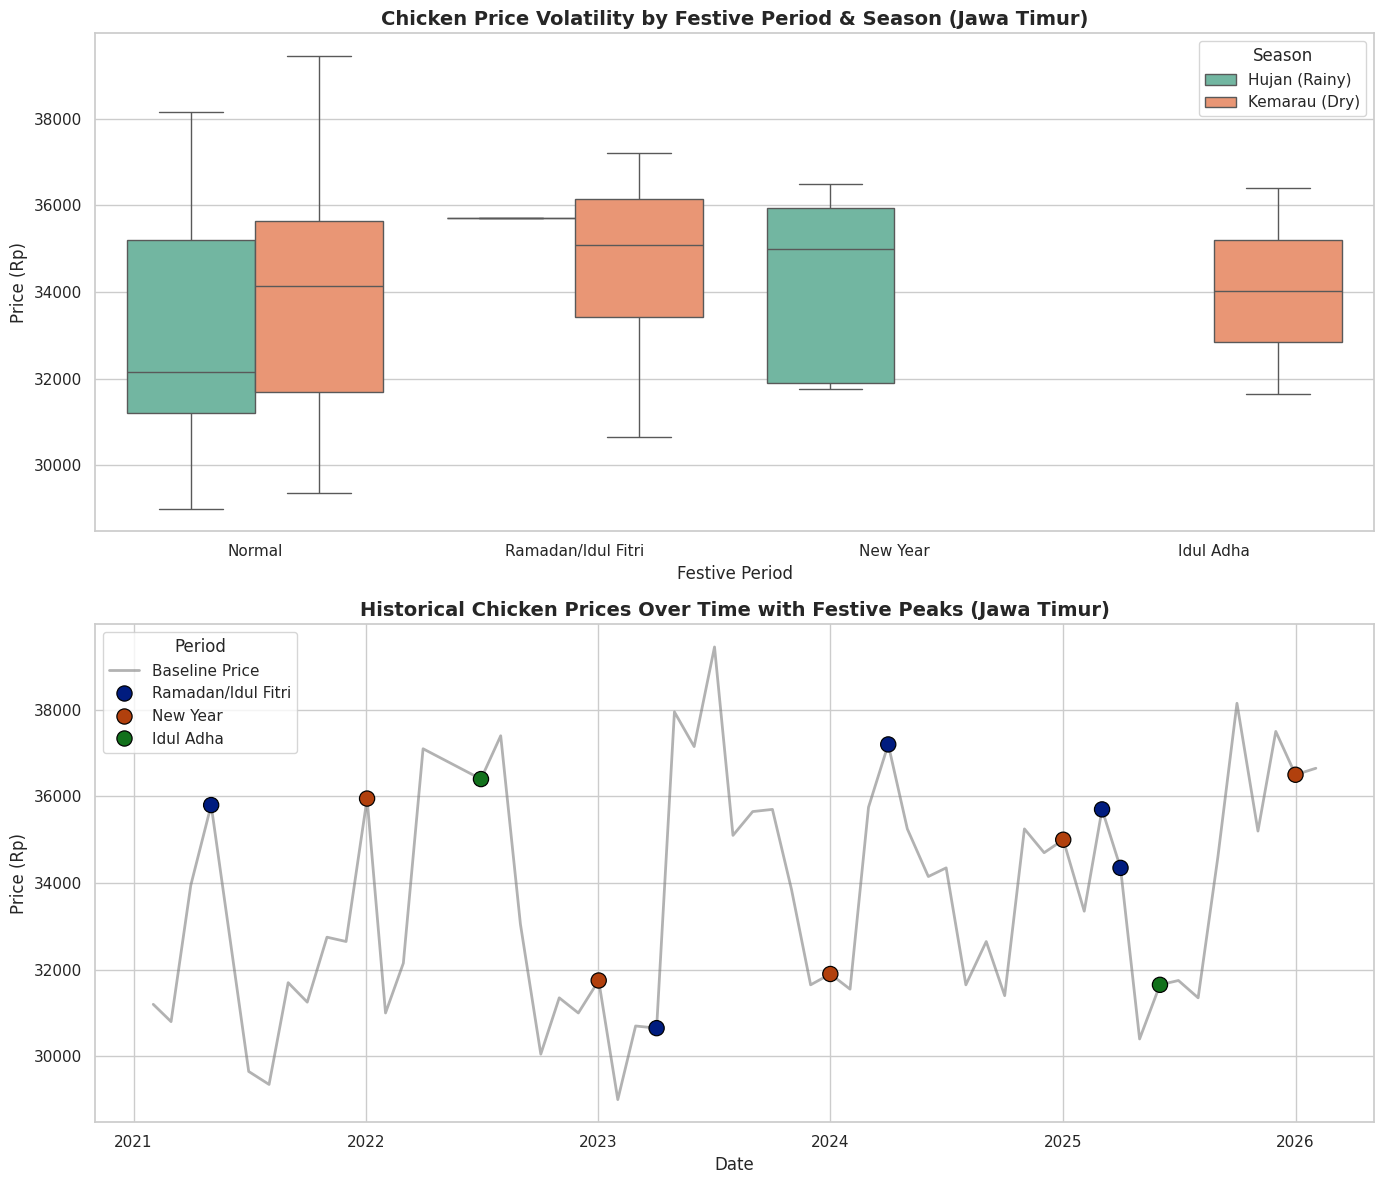

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots stacked vertically
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Data Prep ---
# Filter for Jawa Timur to get localized insights
df_jt = df_long[df_long['Lokasi'].str.contains('Jawa Timur', case=False, na=False)]

# --- Plot 1: Boxplot (Price Distribution by Period & Season) ---
# This shows the median, quartiles, and outliers for each category
sns.boxplot(
    data=df_jt,
    x='Period',
    y='Price',
    hue='Season',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Chicken Price Volatility by Festive Period & Season (Jawa Timur)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (Rp)', fontsize=12)
axes[0].set_xlabel('Festive Period', fontsize=12)

# --- Plot 2: Line Chart (Time Series with Festive Highlights) ---
# First, plot the continuous baseline trend
sns.lineplot(
    data=df_jt,
    x='Date',
    y='Price',
    color='gray',
    alpha=0.6,
    linewidth=2,
    ax=axes[1],
    label='Baseline Price'
)

# Next, overlay scatter points specifically for the festive periods
festive_data = df_jt[df_jt['Period'] != 'Normal']
sns.scatterplot(
    data=festive_data,
    x='Date',
    y='Price',
    hue='Period',
    palette='dark',
    s=120, # Size of the markers
    edgecolor='black',
    ax=axes[1],
    zorder=5 # Ensures the dots sit on top of the line
)

axes[1].set_title('Historical Chicken Prices Over Time with Festive Peaks (Jawa Timur)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (Rp)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)

# Adjust layout to prevent overlap and display the plot
plt.tight_layout()
plt.show()

Calculated CAGR for Jawa Timur: 3.05%


/tmp/ipython-input-385/2809452904.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_jt, x='Period', y='Price_Yearly_Ratio',


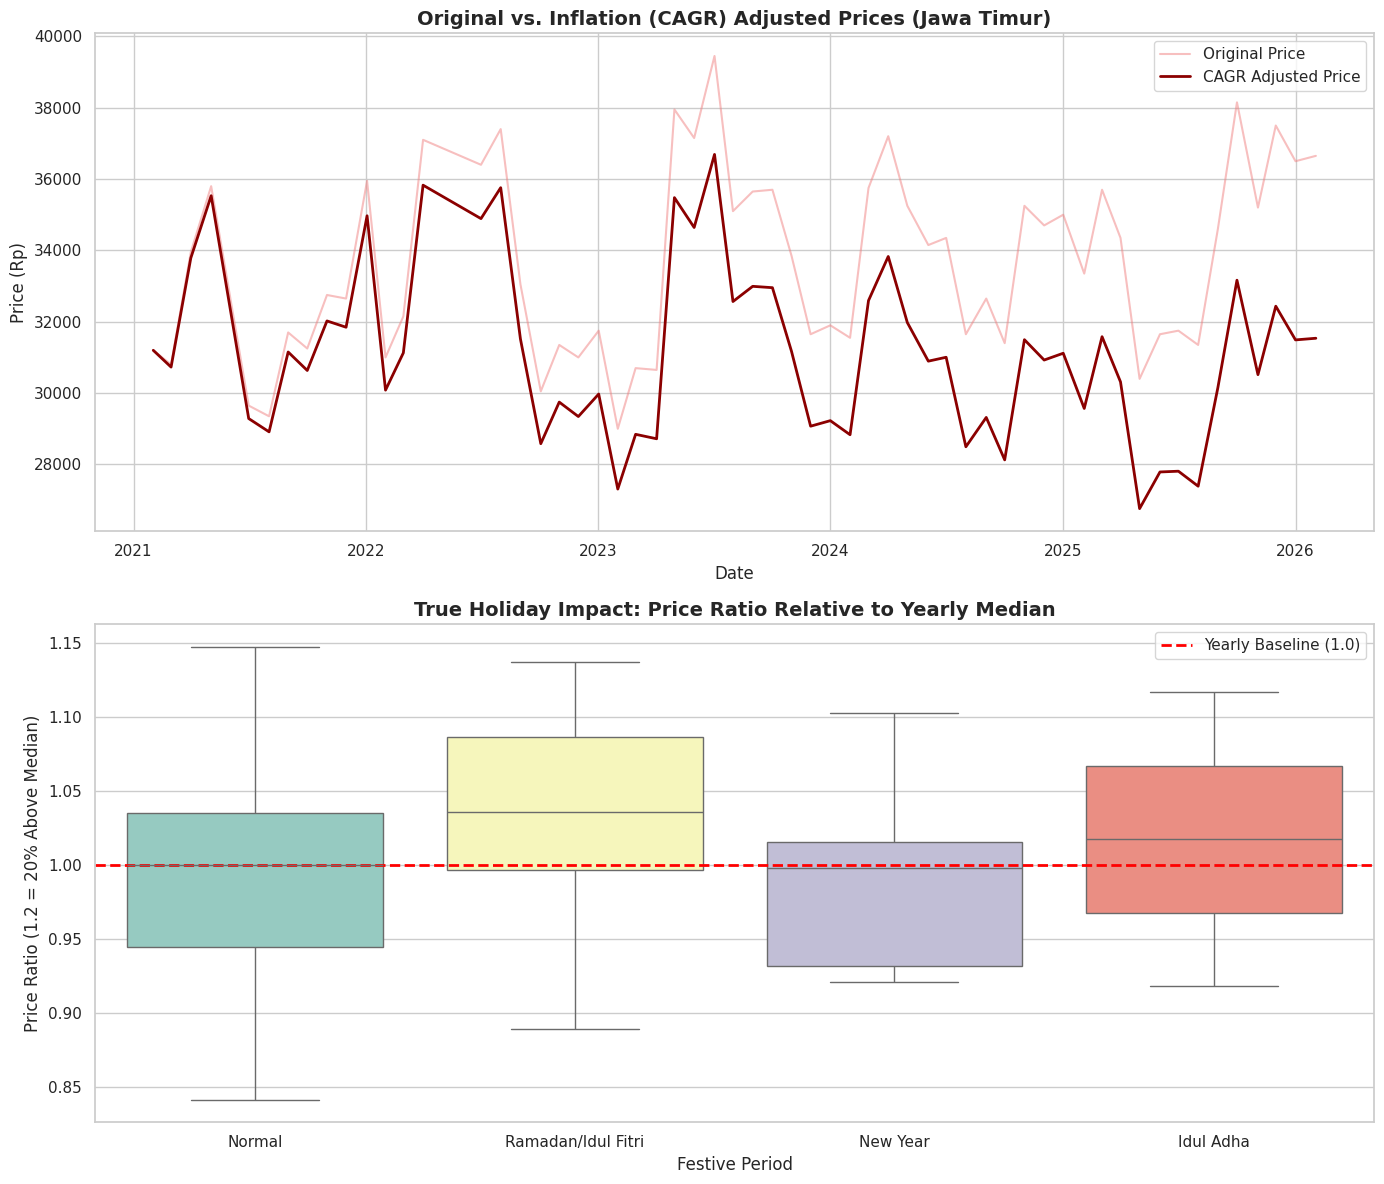

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 0. DATA PREP
# ==========================================
# Cleanly filter for Jawa Timur and create a copy to avoid warnings
df_jt = df_long[df_long['Lokasi'].str.contains('Jawa Timur', case=False, na=False)].copy()

# Extract the specific year
df_jt['Year'] = df_jt['Date'].dt.year


# ==========================================
# METHOD 1: Normalize using CAGR (Corrected)
# ==========================================
start_year = df_jt['Year'].min()
end_year = df_jt['Year'].max()

price_start = df_jt[df_jt['Year'] == start_year]['Price'].median()
price_end = df_jt[df_jt['Year'] == end_year]['Price'].median()

# Calculate n (number of years)
n_years = end_year - start_year

# Safeguard for datasets spanning less than a full year
if n_years > 0:
    cagr = (price_end / price_start)**(1 / n_years) - 1
else:
    cagr = 0.0

print(f"Calculated CAGR for Jawa Timur: {cagr:.2%}")

# Use the exact start date for continuous daily deflation
start_date = df_jt['Date'].min()
df_jt['Years_Since_Start_Continuous'] = (df_jt['Date'] - start_date).dt.days / 365.25

# Apply the continuous adjustment
df_jt['Price_CAGR_Adjusted'] = df_jt['Price'] / ((1 + cagr) ** df_jt['Years_Since_Start_Continuous'])


# ==========================================
# METHOD 2: Normalize by Yearly Median Ratio
# ==========================================
# Calculate the baseline (median) price for each individual year
df_jt['Yearly_Median_Price'] = df_jt.groupby('Year')['Price'].transform('median')

# Create the ratio
df_jt['Price_Yearly_Ratio'] = df_jt['Price'] / df_jt['Yearly_Median_Price']


# ==========================================
# VISUALIZATION
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Original vs. CAGR Adjusted Price
sns.lineplot(data=df_jt, x='Date', y='Price',
             color='lightcoral', alpha=0.5, label='Original Price', ax=axes[0])

sns.lineplot(data=df_jt, x='Date', y='Price_CAGR_Adjusted',
             color='darkred', linewidth=2, label='CAGR Adjusted Price', ax=axes[0])

axes[0].set_title('Original vs. Inflation (CAGR) Adjusted Prices (Jawa Timur)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (Rp)', fontsize=12)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].legend()

# Plot 2: Relative Price Spikes by Period
sns.boxplot(data=df_jt, x='Period', y='Price_Yearly_Ratio',
            palette='Set3', ax=axes[1])

axes[1].axhline(1.0, color='red', linestyle='--', linewidth=2, label='Yearly Baseline (1.0)')

axes[1].set_title('True Holiday Impact: Price Ratio Relative to Yearly Median', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price Ratio (1.2 = 20% Above Median)', fontsize=12)
axes[1].set_xlabel('Festive Period', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
print(df_jt)

        Lokasi       Date    Price Location_Type  Month         Season  \
0   Jawa Timur 2021-02-01  31200.0      Province      2  Hujan (Rainy)   
1   Jawa Timur 2021-03-01  30800.0      Province      3  Hujan (Rainy)   
2   Jawa Timur 2021-04-01  33950.0      Province      4  Kemarau (Dry)   
3   Jawa Timur 2021-05-03  35800.0      Province      5  Kemarau (Dry)   
4   Jawa Timur 2021-07-01  29650.0      Province      7  Kemarau (Dry)   
5   Jawa Timur 2021-08-02  29350.0      Province      8  Kemarau (Dry)   
6   Jawa Timur 2021-09-01  31700.0      Province      9  Kemarau (Dry)   
7   Jawa Timur 2021-10-01  31250.0      Province     10  Hujan (Rainy)   
8   Jawa Timur 2021-11-01  32750.0      Province     11  Hujan (Rainy)   
9   Jawa Timur 2021-12-01  32650.0      Province     12  Hujan (Rainy)   
10  Jawa Timur 2022-01-03  35950.0      Province      1  Hujan (Rainy)   
11  Jawa Timur 2022-02-01  31000.0      Province      2  Hujan (Rainy)   
12  Jawa Timur 2022-03-01  32150.0    

In [20]:
df_jt

,Lokasi,Date,Price,Location_Type,Month,Season,Period,Year,Years_Since_Start_Continuous,Price_CAGR_Adjusted,Yearly_Median_Price,Price_Yearly_Ratio
0,Jawa Timur,2021-02-01,31200.0,Province,2,Hujan (Rainy),Normal,2021,0.000000,31200.000000,31475.0,0.991263
1,Jawa Timur,2021-03-01,30800.0,Province,3,Hujan (Rainy),Normal,2021,0.076660,30729.166976,31475.0,0.978554
2,Jawa Timur,2021-04-01,33950.0,Province,4,Kemarau (Dry),Normal,2021,0.161533,33785.689384,31475.0,1.078634
3,Jawa Timur,2021-05-03,35800.0,Province,5,Kemarau (Dry),Ramadan/Idul Fitri,2021,0.249144,35533.112980,31475.0,1.137411
4,Jawa Timur,2021-07-01,29650.0,Province,7,Kemarau (Dry),Normal,2021,0.410678,29286.531120,31475.0,0.942017
5,Jawa Timur,2021-08-02,29350.0,Province,8,Kemarau (Dry),Normal,2021,0.498289,28914.025908,31475.0,0.932486
6,Jawa Timur,2021-09-01,31700.0,Province,9,Kemarau (Dry),Normal,2021,0.580424,31152.174705,31475.0,1.007149
7,Jawa Timur,2021-10-01,31250.0,Province,10,Hujan (Rainy),Normal,2021,0.662560,30634.286982,31475.0,0.992851
8,Jawa Timur,2021-11-01,32750.0,Province,11,Hujan (Rainy),Normal,2021,0.747433,32022.998477,31475.0,1.040508
9,Jawa Timur,2021-12-01,32650.0,Province,12,Hujan (Rainy),Normal,2021,0.829569,31846.559682,31475.0,1.037331


In [19]:
import scipy.stats as stats
import pandas as pd

# We will test the 'Price_Yearly_Ratio' to ensure we are testing the true
# holiday impact, independent of general inflation.

print("=== STATISTICAL PROOF OF PRICE CONSISTENCY ===\n")

# ---------------------------------------------------------
# TEST 1: Festive Periods (Kruskal-Wallis Test)
# ---------------------------------------------------------
# Group the ratios by the festive period
period_groups = [group['Price_Yearly_Ratio'].values for name, group in df_jt.groupby('Period')]

# Run the Kruskal-Wallis test
h_stat, p_val_period = stats.kruskal(*period_groups)

print("1. FESTIVE PERIOD IMPACT (Kruskal-Wallis Test)")
print(f"   P-value: {p_val_period:.5f}")
if p_val_period < 0.05:
    print("   Conclusion: SIGNIFICANT. The price hikes during specific festive periods happen consistently, not by random chance.")
else:
    print("   Conclusion: NOT SIGNIFICANT. The price differences between periods are not consistent enough to prove a pattern.")

print("\n   --- Post-Hoc Check (Compared to 'Normal') ---")
# If it's significant, let's see exactly WHICH holidays are different from Normal
normal_data = df_jt[df_jt['Period'] == 'Normal']['Price_Yearly_Ratio']
for period in df_jt['Period'].unique():
    if period != 'Normal':
        period_data = df_jt[df_jt['Period'] == period]['Price_Yearly_Ratio']
        # Mann-Whitney U test between Normal and this specific holiday
        stat, p_val_specific = stats.mannwhitneyu(normal_data, period_data, alternative='two-sided')

        # Calculate how much higher/lower the median is
        median_diff = period_data.median() - normal_data.median()
        trend = "HIGHER" if median_diff > 0 else "LOWER"

        if p_val_specific < 0.05:
            print(f"   - {period}: Consistently {trend} than Normal (p={p_val_specific:.4f})")
        else:
            print(f"   - {period}: No consistent difference from Normal (p={p_val_specific:.4f})")


# ---------------------------------------------------------
# TEST 2: Dry vs Rainy Season (Mann-Whitney U Test)
# ---------------------------------------------------------
print("\n\n2. SEASONAL IMPACT (Mann-Whitney U Test)")
hujan_data = df_jt[df_jt['Season'] == 'Hujan (Rainy)']['Price_Yearly_Ratio']
kemarau_data = df_jt[df_jt['Season'] == 'Kemarau (Dry)']['Price_Yearly_Ratio']

u_stat, p_val_season = stats.mannwhitneyu(hujan_data, kemarau_data, alternative='two-sided')

print(f"   P-value: {p_val_season:.5f}")
if p_val_season < 0.05:
    higher_season = "Hujan" if hujan_data.median() > kemarau_data.median() else "Kemarau"
    print(f"   Conclusion: SIGNIFICANT. Prices are consistently higher during the {higher_season} season.")
else:
    print("   Conclusion: NOT SIGNIFICANT. The change between rainy and dry seasons does not consistently impact prices.")

=== STATISTICAL PROOF OF PRICE CONSISTENCY ===

1. FESTIVE PERIOD IMPACT (Kruskal-Wallis Test)
   P-value: 0.87766
   Conclusion: NOT SIGNIFICANT. The price differences between periods are not consistent enough to prove a pattern.

   --- Post-Hoc Check (Compared to 'Normal') ---
   - Ramadan/Idul Fitri: No consistent difference from Normal (p=0.4102)
   - New Year: No consistent difference from Normal (p=0.8992)
   - Idul Adha: No consistent difference from Normal (p=0.9178)


2. SEASONAL IMPACT (Mann-Whitney U Test)
   P-value: 0.26500
   Conclusion: NOT SIGNIFICANT. The change between rainy and dry seasons does not consistently impact prices.


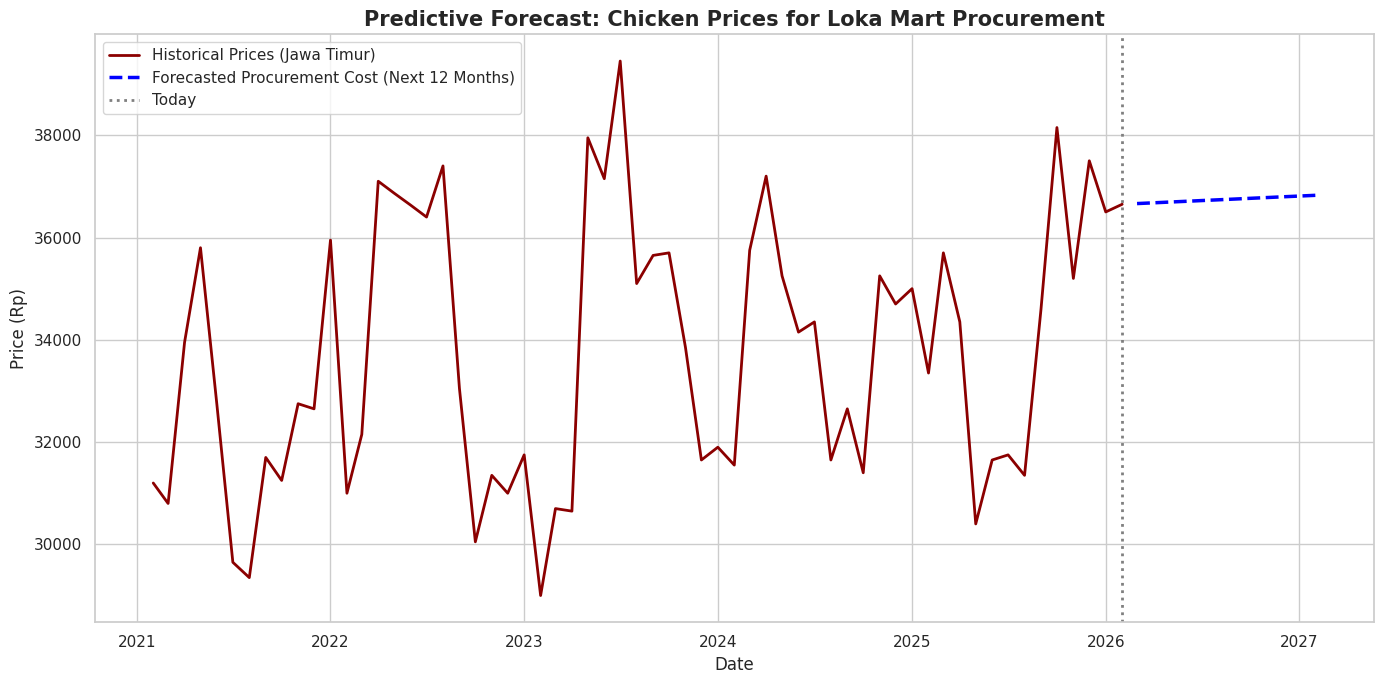

In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# 1. Prepare the data for time-series modeling
ts_data = df_jt[['Date', 'Price']].copy()
ts_data = ts_data.set_index('Date').sort_index()

# Ensure the data has a strict monthly frequency (Month Start) and fill any tiny gaps
ts_data = ts_data.resample('MS').mean().interpolate()

# 2. Fit an Exponential Smoothing model
# We omit heavy seasonality since our tests proved it's inconsistent, but we track the trend
model = ExponentialSmoothing(
    ts_data['Price'],
    trend='add',
    seasonal=None,
    initialization_method="estimated"
)
fit_model = model.fit()

# 3. Forecast the next 12 months
forecast = fit_model.forecast(12)

# 4. Visualize the Historical vs. Forecasted Data
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Plot history
plt.plot(ts_data.index, ts_data['Price'], label='Historical Prices (Jawa Timur)', color='darkred', linewidth=2)

# Plot forecast
plt.plot(forecast.index, forecast, label='Forecasted Procurement Cost (Next 12 Months)', color='blue', linestyle='--', linewidth=2.5)

# Add a vertical line to separate history from forecast
plt.axvline(ts_data.index[-1], color='gray', linestyle=':', linewidth=2, label='Today')

plt.title('Predictive Forecast: Chicken Prices for Loka Mart Procurement', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (Rp)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()